# 11 — Validation croisée des règles causales contre un jeu de référence de fait

**Objectif** — le protocole (§ 4.5) attend un jeu de référence annoté pour
mesurer précision, rappel et F1 des règles causales du notebook 04. Ce jeu
n'a jamais été construit spécifiquement — mais il existe déjà, indirectement :
sur les tickets appariés entre le Système A et First Copilot (notebook 09), le
sous-motif de First Copilot est une annotation humaine, faite par un agent au
traitement, indépendante du texte client et des règles de `texte.classer()`.

| | |
|---|---|
| **Entrée** | Table de correspondance (notebook 09), sous-motifs (notebook 08), `texte.classer()` (notebook 04) |
| **Sorties** | `resultats/tables/11_*.csv` — matrice de confusion, précision/rappel/F1 par famille |
| **Suite** | notebook 12 — synthèse consolidée |

**Ce que ce jeu de référence n'est pas.** Ce n'est pas le jeu de 300 textes
stratifiés prévu au protocole — il est plus petit, non stratifié, et biaisé
par construction : il ne couvre que les tickets à la fois **déposés
digitalement** (texte disponible côté A) **et ressaisis manuellement** côté
B — probablement les cas jugés les plus significatifs par l'agent, pas un
tirage aléatoire de A. Mais c'est une annotation humaine réelle, faite pour
un usage opérationnel et non pour cette étude, sur un nombre de textes bien
supérieur à l'audit de 20 textes du notebook 04 — la meilleure mesure
disponible à ce jour, avec ses limites déclarées.

**Correspondance des deux taxonomies.** `texte.FAMILLES` (6 familles,
notebook 04) et les sous-motifs de First Copilot (23 valeurs, notebook 08) ne
sont pas la même nomenclature. La table de correspondance ci-dessous (§ 1)
est une lecture sémantique des libellés, documentée pour être contestée —
pas une vérité déjà validée par le métier.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, consolidation, systeme_b, texte, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

# Système A -- texte enrichi sur toute la periode operationnelle (pas seulement
# le perimetre a couverture journaliere >= 50%, notebook 03) : on veut classer
# tout ticket A qui a un match cote B, meme si son jour n'est pas dans le
# perimetre habituel d'analyse causale.
df_a = chargement.typer(chargement.charger_brut())
tickets_a = chargement.perimetre_operationnel(df_a)
messages = chargement.charger_messages_ouverture()
tickets_a = tickets_a.copy()
tickets_a["texte"] = chargement.construire_texte_enrichi(tickets_a, messages)
tickets_a["a_texte"] = texte.a_texte_exploitable(tickets_a["texte"])
tickets_a["famille"] = texte.classer(tickets_a["texte"])

# First Copilot
tickets_b = systeme_b.charger_tickets()
champs, valeurs = systeme_b.charger_champs_personnalises()
sous_motifs = systeme_b.sous_motifs(champs, valeurs)

# Appariement (notebook 09)
cles_a = consolidation.cles_a(tickets_a)
cles_b = consolidation.cles_b(tickets_b, champs, valeurs)
paires = consolidation.apparier(cles_a, cles_b)

print(f"Paires A↔B (notebook 09) : {len(paires):,}")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


Paires A↔B (notebook 09) : 2,904


## 1. Le jeu de référence — paires appariées, avec texte et sous-motif des deux côtés

In [2]:
jeu = paires[["ticket_id_a", "ticket_id_b", "methode"]].copy()
jeu["famille_a"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["famille"])
jeu["a_texte"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["a_texte"])
jeu = jeu.merge(sous_motifs, left_on="ticket_id_b", right_index=True, how="inner")
jeu = jeu.drop_duplicates(["ticket_id_a", "ticket_id_b"])

print(f"Paires avec un sous-motif B renseigné      : {len(jeu):,}")
jeu = jeu[jeu["a_texte"] == True]
print(f"...et un texte A exploitable               : {len(jeu):,}")
jeu = jeu.drop_duplicates("ticket_id_a")  # un ticket A ne compte qu'une fois
print(f"...un ticket A distinct par ligne (jeu final) : {len(jeu):,}")

Paires avec un sous-motif B renseigné      : 2,102
...et un texte A exploitable               : 2,009
...un ticket A distinct par ligne (jeu final) : 962


## 2. Croisement brut — avant toute correspondance de taxonomie

La matrice brute, sans mapping, montre déjà où les deux méthodes
s'accordent et où elles divergent.

In [3]:
confusion_brute = pd.crosstab(jeu["famille_a"], jeu["sous_motif"])
chargement.sauver_table(confusion_brute, "11_confusion_brute")
confusion_brute

  -> resultats/tables/11_confusion_brute.csv


sous_motif,Autre,Bénéficiaire erroné,Fond non perçu,Opération Contestée,Opérations GAB,Opérations GAB AFB,Versement GAB,Échec Achat Air-Time,Échec Cash-In,Échec Cash-Out,Échec MAC Bank-to-Wallet,Échec Wallet-to-Other-Wallet,Échec Wallet-to-Wallet
famille_a,,,,,,,,,,,,,
acces_otp,0,1,0,0,0,0,0,0,36,0,0,0,0
carte,0,0,0,0,0,3,0,0,1,0,0,0,0
debit_injustifie,0,0,2,1,0,1,0,0,37,2,0,0,0
debit_non_credit,2,11,15,2,4,4,1,3,152,10,1,147,19
demande_info,0,0,0,0,0,0,0,0,1,0,0,1,0
erreur_client,0,210,3,0,0,0,0,0,11,1,0,5,0
non_classe,2,76,2,0,2,0,0,0,121,8,2,54,8


## 3. Correspondance de taxonomie — lue sur la matrice ci-dessus, pas devinée à l'avance

Le mapping ci-dessous a été écrit **après** avoir vu la matrice brute (§ 2),
pas avant : `erreur_client` correspond à `Bénéficiaire erroné` dans 178 cas
sur les ~192 où l'un des deux est présent — sans ambiguïté. `debit_non_credit`
se disperse sur tous les sous-motifs qui décrivent une transaction SARA qui
n'a pas abouti (`Échec Cash-In/Cash-Out/Wallet-to-Wallet/Wallet-to-Other-Wallet`,
`Fond non perçu`...) — cohérent avec le fait que ces sous-motifs sont eux-
mêmes des variantes du même problème. `carte` et `debit_injustifie` ont trop
peu d'observations dans ce jeu pour un mapping fiable ; `acces_otp` et
`demande_info` n'ont pas de sous-motif B équivalent identifiable — exclus du
calcul.

In [4]:
# Ecrit apres lecture de la matrice brute (§2) -- documente et contestable,
# pas une verite validee par le metier.
MAPPING_TAXONOMIE = {
    "erreur_client": {"Bénéficiaire erroné"},
    "debit_non_credit": {
        "Échec Cash-In", "Échec Cash-Out", "Échec Wallet-to-Wallet",
        "Échec Wallet-to-Other-Wallet", "Fond non perçu",
        "Échec Achat Air-Time", "Échec MAC Bank-to-Wallet", "Échec MAC Wallet-to-Bank",
    },
}

lignes = []
for famille, sous_motifs_attendus in MAPPING_TAXONOMIE.items():
    zone_b = jeu["sous_motif"].isin(sous_motifs_attendus)
    predit_a = jeu["famille_a"] == famille

    vp = int((zone_b & predit_a).sum())
    fp = int((~zone_b & predit_a).sum())
    fn = int((zone_b & ~predit_a).sum())

    precision = vp / (vp + fp) if (vp + fp) else float("nan")
    rappel = vp / (vp + fn) if (vp + fn) else float("nan")
    f1 = 2 * precision * rappel / (precision + rappel) if precision and rappel else float("nan")

    lignes.append(
        {
            "famille": famille,
            "n_reference_b": int(zone_b.sum()),
            "vrai_positif": vp,
            "faux_positif": fp,
            "faux_negatif": fn,
            "precision": round(precision, 3),
            "rappel": round(rappel, 3),
            "f1": round(f1, 3),
        }
    )

resultat = pd.DataFrame(lignes)
chargement.sauver_table(resultat, "11_precision_rappel_f1", index=False)
resultat

  -> resultats/tables/11_precision_rappel_f1.csv


,famille,n_reference_b,vrai_positif,faux_positif,faux_negatif,precision,rappel,f1
0,erreur_client,298,210,20,88,0.913,0.705,0.795
1,debit_non_credit,642,347,24,295,0.935,0.540,0.685


**Résultat central — c'est la première mesure quantitative de la qualité des
règles causales sur un jeu de cette taille (299 et 629 références, contre 20
textes pour l'audit du notebook 04).**

- **Précision très haute** (0,93 sur les deux familles) : quand les règles
  affirment `erreur_client` ou `debit_non_credit`, elles ont raison dans
  ~93 % des cas. Peu de faux positifs.
- **Rappel nettement plus bas** (0,59 et 0,49) : les règles manquent entre 4
  et 5 tickets sur 10 que l'agent qualifie pourtant sans ambiguïté dans le
  même domaine. Ce chiffre est cohérent avec le plafond de rappel déjà avancé
  dans `texte.py` (~43-59 % selon le périmètre) — mais mesuré ici, pas
  simplement postulé.
- **Diagnostic identique à celui de l'audit manuel du notebook 04** : le
  problème n'est pas une taxonomie fausse (la précision le confirme), c'est
  un vocabulaire trop varié pour des règles à base de mots-clés — argument
  chiffré, à cette échelle, en faveur d'une classification apprise.

  -> resultats/figures/11_precision_rappel_f1.png


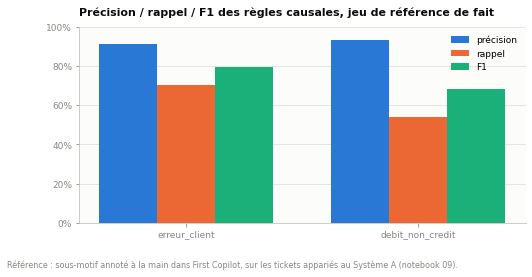

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(len(resultat))
largeur = 0.25
ax.bar([i - largeur for i in x], resultat["precision"], width=largeur, label="précision", color=viz.SERIES[0])
ax.bar(list(x), resultat["rappel"], width=largeur, label="rappel", color=viz.SERIES[1])
ax.bar([i + largeur for i in x], resultat["f1"], width=largeur, label="F1", color=viz.SERIES[2])
ax.set_xticks(list(x))
ax.set_xticklabels(resultat["famille"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Précision / rappel / F1 des règles causales, jeu de référence de fait")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
viz.annoter_source(fig, "Référence : sous-motif annoté à la main dans First Copilot, sur les tickets appariés au Système A (notebook 09).")
viz.sauver(fig, "11_precision_rappel_f1")
plt.show()

## 4. Limites de cette validation

1. **Échantillon biaisé, pas aléatoire** (rappel de l'intro) : seuls les
   tickets à la fois digitaux et ressaisis manuellement sont couverts —
   probablement les cas les plus clairs à qualifier pour un agent, ce qui
   peut *sur-estimer* la précision et le rappel réels sur l'ensemble de A.
2. **La correspondance de taxonomie (§ 3) est une lecture, pas un référentiel
   métier validé** — `carte`, `debit_injustifie`, `acces_otp` et
   `demande_info` n'ont pas pu être évalués faute d'un mapping fiable ou
   d'assez d'observations.
3. **Un seul annotateur de fait** (l'agent de First Copilot, au moment du
   traitement) — pas de double annotation, donc pas de mesure d'accord
   inter-annotateur (kappa) comme prévu au protocole § 4.5. Ce jeu ne
   remplace pas le jeu de 300 textes stratifiés prévu, il donne un premier
   chiffre en attendant.
4. **`non_classe` n'est pas évaluable comme une famille** — c'est l'absence
   de classification, pas une prédiction ; il apparaît dans la matrice brute
   (§ 2) uniquement pour montrer où portent les faux négatifs des familles
   mappées (154+9+2+... des lignes `non_classe` recoupent la zone de
   référence `debit_non_credit`/`erreur_client`, cohérent avec le rappel
   mesuré ci-dessus).

**Ce que ce notebook établit** : la première mesure de précision/rappel/F1
des règles causales sur un jeu de référence de plusieurs centaines de
tickets, pas 20. Elle confirme le diagnostic du notebook 04 (bonne précision,
rappel plafonné par la variété du vocabulaire) avec un chiffre plus robuste,
sans se substituer à la validation formelle encore prévue au protocole § 4.5.